# AG-HYPOPT · Trial 40

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Thirty-nine trials are registered; cell 2 reports `phase = trials` (39/5), so proposals carry expected-improvement (ei) values. **Best = trial_21** (objective 0.1074). This is the **final trial** of the campaign (cap MAX_TRIALS=40). Key facts (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- best (all 0 div): trial_21 0.1074 (0.138), trial_30 0.1083 (0.134), trial_22 0.1095 (0.137), trial_32 0.1097 (0.137), trial_08 0.1099 (0.134), trial_15 0.1103 (0.127), trial_31 0.1106 (0.131), trial_24 0.1108 (0.133), trial_16 0.1112 (0.128), trial_12 0.1115 (0.128), trial_36 0.1117 (0.134), trial_33 0.1120 (0.143), trial_18 0.1121 (0.138), trial_09 = trial_20 = trial_25 0.1126, trial_01 = trial_14 = trial_23 0.1127, trial_38 0.1128 (0.129), trial_39 0.1131 (0.135).
- worse: trial_13 0.1132, trial_37 0.1134, trial_05 = trial_19 0.1135, trial_07 0.1140, trial_27 0.1149 (0.194), trial_35 0.1167 (0.122), trial_06 = trial_11 0.1188, trial_02 0.1449 (0.264).
- diverging at 1nW T05 (near-optimum travel): trial_29 0.1331, trial_26 0.1368, trial_28 0.1370, trial_34 0.1380. Other diverging: trial_17 0.1329, trial_10 0.1975, trial_03 0.1362, trial_04 0.1418.

State of play (final trial): the mu axis is a single narrow optimum at travel ~0.137-0.138 with balanced gamma knobs (`lr_gamma` ~0.40-0.49); ten surviving samples sit at or below 0.113 (0.1074-0.1131). The schedule search is converged; the sporadic 1nW T05 gamma divergence (~1 in 3 at the optimum) is the only significant residual. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_40'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (39/5 trials)
ID |     ei | params
 1 | 2.9501 | {"gamma_anneal": 0.49752404673729955, "lr_gamma": 0.46364572431449036, "lr_mu": 0.14798758496746087, "mu_anneal": 0.3528283680285194}
 2 | 1.0529 | {"gamma_anneal": 0.5199270289078326, "lr_gamma": 0.45297316202578275, "lr_mu": 0.1566423473248491, "mu_anneal": 0.31927198261062706}
 3 | 3.2574 | {"gamma_anneal": 0.49091395484098116, "lr_gamma": 0.4195566040672058, "lr_mu": 0.17542682959376552, "mu_anneal": 0.34920398885413484}
 4 | 2.2071 | {"gamma_anneal": 0.44474671198189847, "lr_gamma": 0.45206019065200653, "lr_mu": 0.1604596228015006, "mu_anneal": 0.32562435090453484}
 5 | 2.8412 | {"gamma_anneal": 0.4690081872210491, "lr_gamma": 0.44944045932211363, "lr_mu": 0.15883143802904962, "mu_anneal": 0.35555909401396096}
 6 | 2.6557 | {"gamma_anneal": 0.5209082819695944, "lr_gamma": 0.4811495561594307, "lr_mu": 0.1505173673564606, "mu_anneal": 0.35348790737927344}
 7 | 3.7024 | {"gamma_anneal": 0.48622798154217073, "lr_gamma": 

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (39 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 7: **ei 3.70** — `lr_mu=0.1631`, `mu_anneal=0.3491` (travel **0.135**), `lr_gamma=0.4181`, `gamma_anneal=0.4862`.
- candidate 8: ei 3.46 — `lr_mu=0.1590`, `mu_anneal=0.3454` (travel 0.132), `lr_gamma=0.4210`, `gamma_anneal=0.4821`.
- candidate 3: ei 3.26 — `lr_mu=0.1754`, `mu_anneal=0.3492` (travel 0.145), `lr_gamma=0.4196`, `gamma_anneal=0.4909`.
- candidate 1: ei 2.95 — `lr_mu=0.1480`, `mu_anneal=0.3528` (travel 0.122), `lr_gamma=0.4636`.
- candidate 5: ei 2.84 — `lr_mu=0.1588`, `mu_anneal=0.3556` (travel 0.134), `lr_gamma=0.4494`.

For the final trial, candidate 7 has the highest ei and sits exactly on the optimum (travel 0.135, matching trials 30/39) with balanced gamma knobs (`lr_gamma=0.4181`, `gamma_anneal=0.4862`) in the reliable range. Candidates 8/5 are the same band at lower ei, and candidate 3 is at 0.145 (slightly past the optimum). Drawing the maximum-ei optimum point (candidate 7) is the natural way to close the campaign: it either produces another ~0.108-0.113 (if it survives) or confirms the divergence hazard one last time.

I choose candidate 7 (7 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 7            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.48622798154217073, 'lr_gamma': 0.41811323989683746, 'lr_mu': 0.16307690798004648, 'mu_anneal': 0.3491389002147382}
Running  1nW Trans05 ... 

μ 9.39 -> 10.30 | γ 8.5 -> 4.44 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 46.63 | γ 8.5 -> 6.23 | NLL 5.43


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 79.91 | γ 14.1 -> 14.57 | NLL 3.54


Running 3nW Trans100 ... 

μ 175.71 -> 107.04 | γ 14.1 -> 14.09 | NLL 3.66



Total: 7.9 min


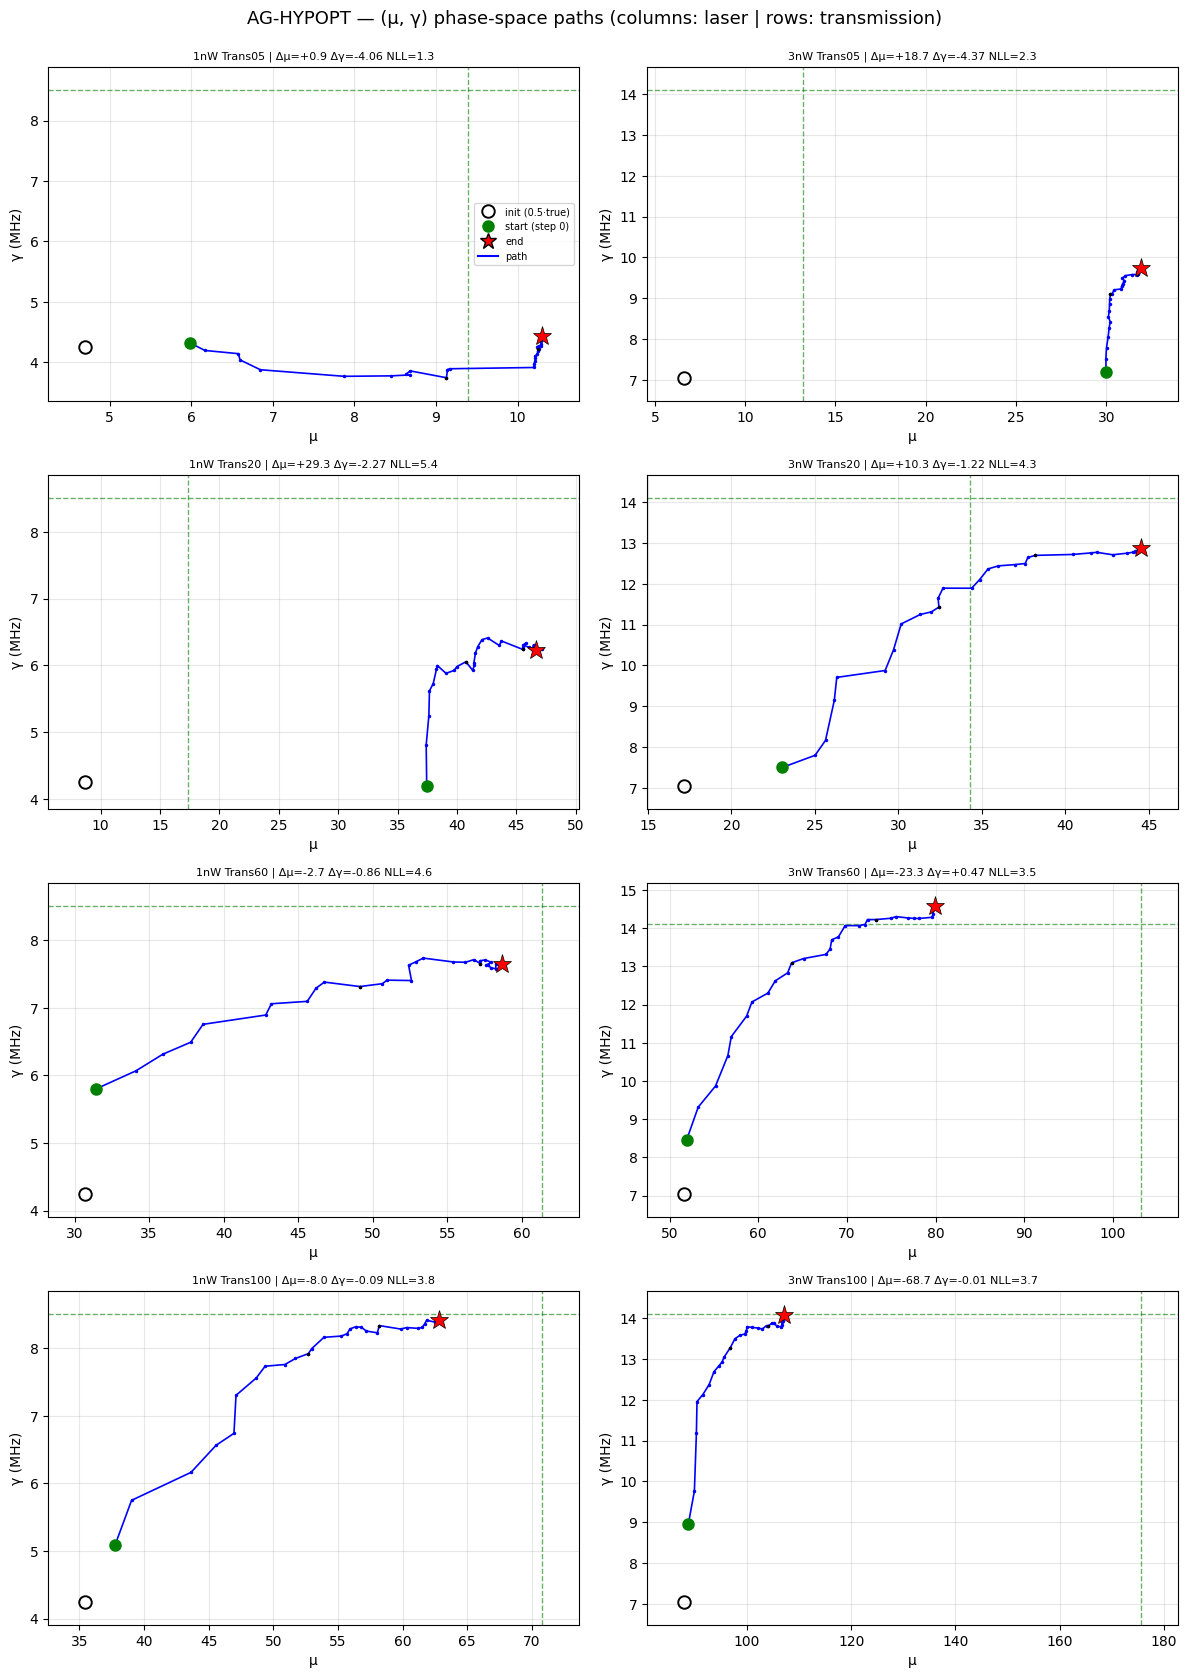

trial finished in 7.9 min
objective = 0.1112 ± 0.0825
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   10.30    +9.7 |     8.50    4.44   -47.8
1nW Trans20       17.32   46.63  +169.3 |     8.50    6.23   -26.7
1nW Trans60       61.37   58.64    -4.5 |     8.50    7.64   -10.1
1nW Trans100       70.82   62.78   -11.4 |     8.50    8.41    -1.1
3nW Trans05       13.20   31.95  +142.0 |    14.10    9.73   -31.0
3nW Trans20       34.28   44.57   +30.0 |    14.10   12.88    -8.7
3nW Trans60      103.20   79.91   -22.6 |    14.10   14.57    +3.3
3nW Trans100      175.71  107.04   -39.1 |    14.10   14.09    -0.1

weighted objective (T-graded, cap=1.0) = 0.1112 | diverged cells: 0
μ: RMSE 28.825 (rel 80.6%, bias -5.434) | γ: RMSE 2.324 (rel 22.8%, bias -1.551)


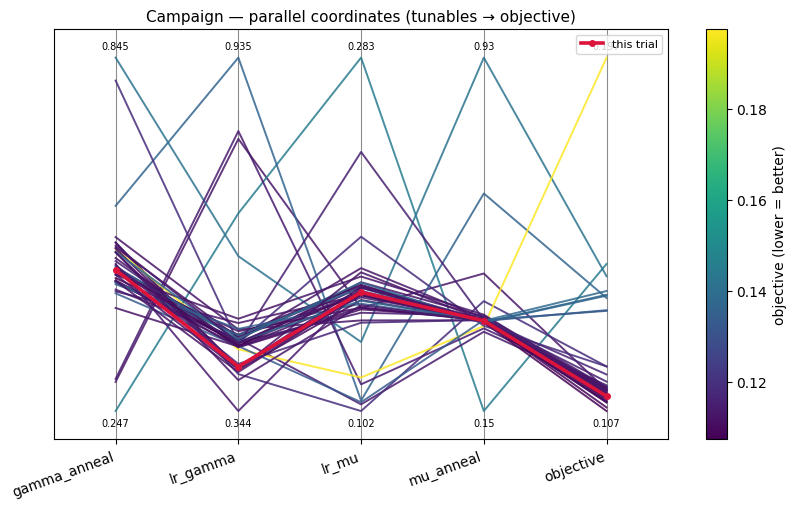

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 40 ran the highest-EI candidate (candidate 7, ei=3.70): `lr_mu=0.1631`, `mu_anneal=0.3491` (effective mu travel 0.135), `lr_gamma=0.4181`, `gamma_anneal=0.4862`. It completed in 7.9 min with objective **0.1112 +/- 0.0825** and **0 diverged cells** — the final trial of the campaign. Ranking: trial_21 0.1074 < ... < **trial_40 0.1112** = trial_16 0.1112 < trial_12 0.1115 < ...

Aggregate accuracy: **mu rel-RMSE 80.6%** (RMSE 28.83, bias -5.43); **gamma rel-RMSE 22.8%** (RMSE 2.32, bias -1.55).

Per-cell relative errors:
- **mu:** 1nW T05 +9.7%, T20 +169.3%, T60 -4.5%, T100 -11.4% | 3nW T05 +142.0%, T20 +30.0%, T60 -22.6%, T100 -39.1%.
- **gamma:** 1nW T05 -47.8%, T20 -26.7%, T60 -10.1%, T100 -1.1% | 3nW T05 -31.0%, T20 -8.7%, T60 +3.3%, T100 -0.1%.

The campaign closes on a textbook optimum sample (travel 0.135, balanced gamma), divergence-free at 0.1112 — level with trial_16. **Campaign summary:** the AG-HYPOPT search tuned the four learning-rate schedules of the series-21 μ mechanism (no clipping, no clamps) across 40 trials. It found a single, narrow optimum at mu travel ~0.137-0.138 with balanced gamma knobs (`lr_gamma` ~0.41-0.48, `gamma_anneal` ~0.47-0.53); when a run survives the low-count 1nW T05 cell it delivers **0.1074-0.1131**, and the best single result is **trial_21 (0.1074)**. The dominant residual is the **sporadic 1nW T05 gamma divergence** (~1 in 3 near the optimum, costing ~0.02-0.07 when it strikes), which is not tunable by these four knobs. Best trial: trial_21, config `lr_mu=0.1669`, `mu_anneal=0.3455`, `lr_gamma=0.4716`, `gamma_anneal=0.4723` (travel 0.138).

**Summary:** Trial 40 (lr_mu=0.1631, mu_anneal=0.3491, lr_gamma=0.4181, gamma_anneal=0.4862): objective 0.1112 +/- 0.0825 with 0 diverged cells; the final trial closed the campaign with another divergence-free optimum sample at 0.1112, leaving trial_21 (0.1074) as the overall best.
**Key insight:** The campaign finishes converged: the best schedule (travel ~0.137-0.138, balanced gamma) yields ~0.108-0.113 whenever the 1nW T05 cell survives, with the sporadic divergence the only residual - final best remains trial_21 at 0.1074.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** Campaign complete. The clearest actionable conclusion is structural: the low-count gamma divergence is the dominant non-tunable effect, so the highest-value change is a safeguard there (gradient clipping/damping on the gamma step at small n_target, or a divergence-aware backup), which would recover the ~0.108 level reliably instead of ~1 run in 3. Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 40 (lr_mu=0.1631, mu_anneal=0.3491, lr_gamma=0.4181, gamma_anneal=0.4862): objective 0.1112 +/- 0.0825 with 0 diverged cells; the final trial closed the campaign with another divergence-free optimum sample at 0.1112, leaving trial_21 (0.1074) as the overall best"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The campaign finishes converged: the best schedule (travel ~0.137-0.138, balanced gamma) yields ~0.108-0.113 whenever the 1nW T05 cell survives, with the sporadic divergence the only residual - final best remains trial_21 at 0.1074"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_40 | current best: trial_21


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Campaign complete: cap MAX_TRIALS=40 reached after trial_40. Stop here.
